In [1]:
import sagemaker
from sagemaker import get_execution_role

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [2]:
import pandas as pd

df = pd.read_csv("final_airbnb_ml.csv")
df.head()

,306,4,4.8,531,FALSE,FALSE.1,FALSE.2,FALSE.3,FALSE.4,FALSE.5,...,FALSE.655,FALSE.656,FALSE.657,FALSE.658,FALSE.659,FALSE.660,FALSE.661,FALSE.662,FALSE.663,FALSE.664
0,485,4,4.7,146,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,119,4,4.9,515,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,192,5,4.9,88,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,232,1,4.9,222,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,261,1,4.8,555,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [3]:
print(df.shape)
print(df.columns.tolist())

(952, 671)
['306', '4', '4.8', '531', 'FALSE', 'FALSE.1', 'FALSE.2', 'FALSE.3', 'FALSE.4', 'FALSE.5', 'FALSE.6', 'FALSE.7', 'FALSE.8', 'TRUE', 'FALSE.9', 'FALSE.10', 'FALSE.11', 'FALSE.12', 'FALSE.13', 'FALSE.14', 'FALSE.15', 'FALSE.16', 'FALSE.17', 'FALSE.18', 'FALSE.19', 'FALSE.20', 'FALSE.21', 'FALSE.22', 'FALSE.23', 'FALSE.24', 'FALSE.25', 'FALSE.26', 'FALSE.27', 'FALSE.28', 'FALSE.29', 'FALSE.30', 'FALSE.31', 'FALSE.32', 'FALSE.33', 'FALSE.34', 'FALSE.35', 'FALSE.36', 'FALSE.37', 'FALSE.38', 'FALSE.39', 'FALSE.40', 'FALSE.41', 'FALSE.42', 'FALSE.43', 'FALSE.44', 'FALSE.45', 'FALSE.46', 'FALSE.47', 'FALSE.48', 'FALSE.49', 'FALSE.50', 'FALSE.51', 'FALSE.52', 'FALSE.53', 'FALSE.54', 'FALSE.55', 'FALSE.56', 'FALSE.57', 'FALSE.58', 'FALSE.59', 'FALSE.60', 'FALSE.61', 'FALSE.62', 'FALSE.63', 'FALSE.64', 'FALSE.65', 'FALSE.66', 'FALSE.67', 'FALSE.68', 'FALSE.69', 'FALSE.70', 'FALSE.71', 'FALSE.72', 'FALSE.73', 'FALSE.74', 'FALSE.75', 'FALSE.76', 'FALSE.77', 'FALSE.78', 'FALSE.79', 'FALSE

In [4]:
df = df.replace({True: 1, False: 0})
df.head()

/tmp/ipykernel_9467/1757821305.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,306,4,4.8,531,FALSE,FALSE.1,FALSE.2,FALSE.3,FALSE.4,FALSE.5,...,FALSE.655,FALSE.656,FALSE.657,FALSE.658,FALSE.659,FALSE.660,FALSE.661,FALSE.662,FALSE.663,FALSE.664
0,485,4,4.7,146,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,119,4,4.9,515,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,192,5,4.9,88,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,232,1,4.9,222,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,261,1,4.8,555,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
cols = ['price(in_dollar)'] + [col for col in df.columns if col != 'price(in_dollar)']
df = df[cols]

df.to_csv("sagemaker_train.csv", index=False, header=False)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 cols = ['price(in_dollar)'] + [col for col in df.columns if col != 'price(in_dollar)']       │
│ ❱ 2 df = df[cols]                                                                                │
│   3                                                                                              │
│   4 df.to_csv("sagemaker_train.csv", index=False, header=False)                                  │
│   5                                                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:4119 in  │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4116 │   │   else:                                                                            │
│    4117 │   │   │   if is_iterator(key):                                                         │
│    4118 │   │   │   │   key = list(key)                                                          │
│ ❱  4119 │   │   │   indexer = self.columns._get_indexer_strict(key, "columns")[1]                │
│    4120 │   │                                                                                    │
│    4121 │   │   # take() does not accept boolean indexers                                        │
│    4122 │   │   if getattr(indexer, "dtype", None) == bool:                                      │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:6 │
│ 212 in _get_indexer_strict                                                                       │
│                                                                                                  │
│   6209 │   │   else:                                                                             │
│   6210 │   │   │   keyarr, indexer, new_indexer = self._reindex_non_unique(keyarr)               │
│   6211 │   │                                                                                     │
│ ❱ 6212 │   │   self._raise_if_missing(keyarr, indexer, axis_name)                                │
│   6213 │   │                                                                                     │
│   6214 │   │   keyarr = self.take(indexer)                                                       │
│   6215 │   │   if isinstance(key, Index):                                                        │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:6 │
│ 264 in _raise_if_missing                                                                         │
│                                                                                                  │
│   6261 │   │   │   │   raise KeyError(f"None of [{key}] are in the [{axis_name}]")               │
│   6262 │   │   │                                                                                 │
│   6263 │   │   │   not_found = list(ensure_index(key)[missing_mask.nonzero()[0]].unique())       │
│ ❱ 6264 │   │   │   raise KeyError(f"{not_found} not in index")                                   │
│   6265 │                                                                                         │
│   6266 │   @overload                                       

In [6]:
with open("sagemaker_train.csv", "r") as f:
    for i in range(3):
        print(f.readline())

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 with open("sagemaker_train.csv", "r") as f:                                                  │
│   2 │   for i in range(3):                                                                       │
│   3 │   │   print(f.readline())                                                                  │
│   4                                                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/IPython/core/interactiveshell │
│ .py:344 in _modified_open                                                                        │
│                                                                                                  │
│    341 │   │   │   "you can use builtins' open."                                                 │
│    342 │   │   )                                                                                 │
│    343 │                                                                                         │
│ ❱  344 │   return io_open(file, *args, **kwargs)                                                 │
│    345                                                                                           │
│    346                                                                                           │
│    347 class InteractiveShell(SingletonConfigurable):                                            │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
FileNotFoundError: [Errno 2] No such file or directory: 'sagemaker_train.csv'

In [8]:
print('price(in_dollar)' in df.columns)

False


In [9]:
df.to_csv("sagemaker_train.csv", index=False, header=False)

In [10]:
import os
print(os.listdir())

['final_airbnb_ml.csv', 'lost+found', '.ipynb_checkpoints', '.virtual_documents', 'airbnb.csv', 'sagemaker_train.csv', 'Untitled1.ipynb', '.sparkmagic', '.Trash-1000']


In [11]:
import sagemaker
from sagemaker import get_execution_role

session = sagemaker.Session()
bucket = session.default_bucket()
role = get_execution_role()

print("Bucket:", bucket)
print("Role:", role)

Bucket: sagemaker-ca-central-1-263245924849
Role: arn:aws:iam::263245924849:role/service-role/AmazonSageMaker-ExecutionRole-20260323T193815


In [12]:
s3_path = session.upload_data(
    path="sagemaker_train.csv",
    bucket=bucket,
    key_prefix="airbnb-price-project"
)

print("S3 Path:", s3_path)

S3 Path: s3://sagemaker-ca-central-1-263245924849/airbnb-price-project/sagemaker_train.csv


In [13]:
train_df = pd.read_csv("sagemaker_train.csv", header=None)
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,661,662,663,664,665,666,667,668,669,670
0,485,4,4.7,146,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,119,4,4.9,515,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,192,5,4.9,88,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,232,1,4.9,222,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,261,1,4.8,555,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
X = train_df.iloc[:, 1:]
y = train_df.iloc[:, 0]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_pred = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 74.70068062827224
R2 Score: 0.2725460882792329


In [18]:
import joblib

joblib.dump(rf_model, "airbnb_price_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [19]:
import os
print(os.listdir())

['final_airbnb_ml.csv', 'lost+found', '.ipynb_checkpoints', '.virtual_documents', 'airbnb.csv', 'airbnb_price_model.pkl', 'sagemaker_train.csv', 'Untitled1.ipynb', '.sparkmagic', '.Trash-1000']


In [23]:
!pip install seaborn

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['price(in_dollar)'], bins=30, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price (in Dollar)")
plt.ylabel("Count")
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:3 │
│ 812 in get_loc                                                                                   │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'price(in_dollar)'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 plt.figure(figsize=(8,5))                                                                    │
│ ❱ 2 sns.histplot(df['price(in_dollar)'], bins=30, kde=True)                                      │
│   3 plt.title("Distribution of Airbnb Prices")                                                   │
│   4 plt.xlabel("Price (in Dollar)")                                                              │
│   5 plt.ylabel("Count")                                                                          │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:4113 in  │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):                                                      │
│    4115 │   │   │   │   indexer = [indexer]                                                      │
│    4116 │   │   else:                                       

<Figure size 800x500 with 0 Axes>

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['beds'], y=df['price(in_dollar)'])
plt.title("Beds vs Airbnb Price")
plt.xlabel("Number of Beds")
plt.ylabel("Price (in Dollar)")
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:3 │
│ 812 in get_loc                                                                                   │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'beds'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 plt.figure(figsize=(8,5))                                                                    │
│ ❱ 2 sns.scatterplot(x=df['beds'], y=df['price(in_dollar)'])                                      │
│   3 plt.title("Beds vs Airbnb Price")                                                            │
│   4 plt.xlabel("Number of Beds")                                                                 │
│   5 plt.ylabel("Price (in Dollar)")                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:4113 in  │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):                                                      │
│    4115 │   │   │   │   indexer = [indexer]                                                      │
│    4116 │   │   else:                                                   

<Figure size 800x500 with 0 Axes>

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rating'], y=df['price(in_dollar)'])
plt.title("Rating vs Airbnb Price")
plt.xlabel("Rating")
plt.ylabel("Price (in Dollar)")
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:3 │
│ 812 in get_loc                                                                                   │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'rating'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 plt.figure(figsize=(8,5))                                                                    │
│ ❱ 2 sns.scatterplot(x=df['rating'], y=df['price(in_dollar)'])                                    │
│   3 plt.title("Rating vs Airbnb Price")                                                          │
│   4 plt.xlabel("Rating")                                                                         │
│   5 plt.ylabel("Price (in Dollar)")                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:4113 in  │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):                                                      │
│    4115 │   │   │   │   indexer = [indexer]                                                      │
│    4116 │   │   else:                                                 

<Figure size 800x500 with 0 Axes>

In [28]:
[col for col in df.columns if 'rating' in col.lower()]

[]

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['num_reviews'], y=df['price(in_dollar)'])
plt.title("Number of Reviews vs Airbnb Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (in Dollar)")
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/indexes/base.py:3 │
│ 812 in get_loc                                                                                   │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'num_reviews'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:2                                                                                    │
│                                                                                                  │
│   1 plt.figure(figsize=(8,5))                                                                    │
│ ❱ 2 sns.scatterplot(x=df['num_reviews'], y=df['price(in_dollar)'])                               │
│   3 plt.title("Number of Reviews vs Airbnb Price")                                               │
│   4 plt.xlabel("Number of Reviews")                                                              │
│   5 plt.ylabel("Price (in Dollar)")                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:4113 in  │
│ __getitem__                                                                                      │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):                                                      │
│    4115 │   │   │   │   indexer = [indexer]                                                      │
│    4116 │   │   else:                                            

<Figure size 800x500 with 0 Axes>

In [30]:
[col for col in df.columns if 'review' in col.lower()]

[]

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_airbnb_ml.csv")
df = df.replace({True: 1, False: 0})

print(df.shape)
df.head()

(952, 671)


/tmp/ipykernel_9467/3740061375.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,306,4,4.8,531,FALSE,FALSE.1,FALSE.2,FALSE.3,FALSE.4,FALSE.5,...,FALSE.655,FALSE.656,FALSE.657,FALSE.658,FALSE.659,FALSE.660,FALSE.661,FALSE.662,FALSE.663,FALSE.664
0,485,4,4.7,146,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,119,4,4.9,515,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,192,5,4.9,88,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,232,1,4.9,222,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,261,1,4.8,555,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_airbnb_ml.csv")
print(df.shape)
print(df.columns.tolist()[:10])
df.head()

(952, 671)
['306', '4', '4.8', '531', 'FALSE', 'FALSE.1', 'FALSE.2', 'FALSE.3', 'FALSE.4', 'FALSE.5']


,306,4,4.8,531,FALSE,FALSE.1,FALSE.2,FALSE.3,FALSE.4,FALSE.5,...,FALSE.655,FALSE.656,FALSE.657,FALSE.658,FALSE.659,FALSE.660,FALSE.661,FALSE.662,FALSE.663,FALSE.664
0,485,4,4.7,146,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,119,4,4.9,515,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,192,5,4.9,88,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,232,1,4.9,222,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,261,1,4.8,555,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
df = pd.read_csv("final_airbnb_ml.csv", header=None)

# rename first important columns
new_cols = ['price(in_dollar)', 'beds', 'rating', 'num_reviews'] + [f'feature_{i}' for i in range(4, df.shape[1])]
df.columns = new_cols

print(df.shape)
print(df.columns[:10])
df.head()

(953, 671)
Index(['price(in_dollar)', 'beds', 'rating', 'num_reviews', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9'],
      dtype='object')


,price(in_dollar),beds,rating,num_reviews,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_661,feature_662,feature_663,feature_664,feature_665,feature_666,feature_667,feature_668,feature_669,feature_670
0,306,4,4.8,531,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,485,4,4.7,146,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,119,4,4.9,515,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,192,5,4.9,88,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,232,1,4.9,222,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


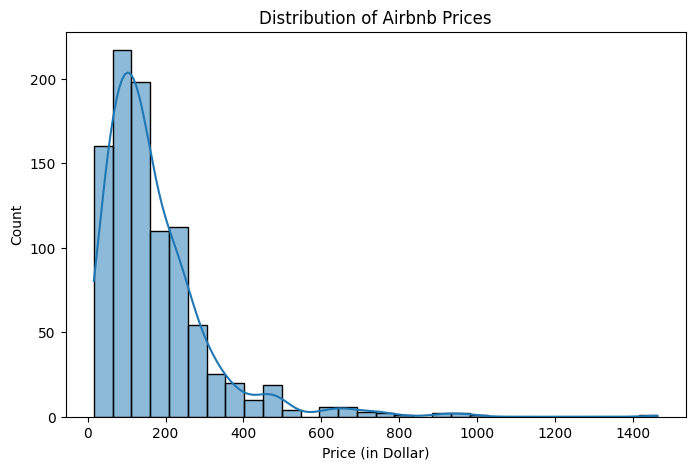

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['price(in_dollar)'], bins=30, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price (in Dollar)")
plt.ylabel("Count")
plt.show()

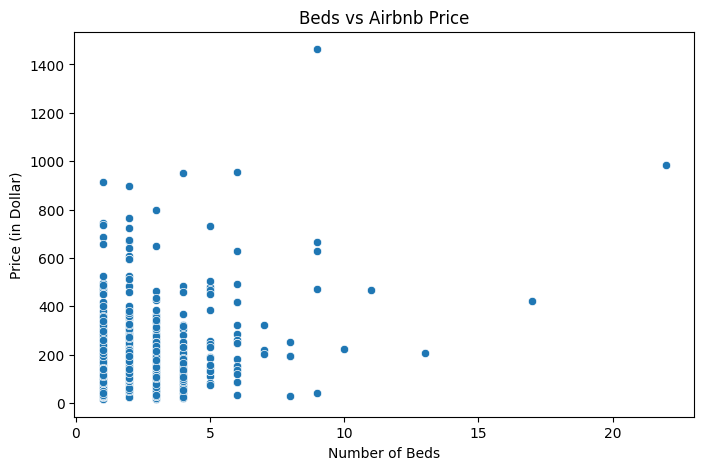

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['beds'], y=df['price(in_dollar)'])
plt.title("Beds vs Airbnb Price")
plt.xlabel("Number of Beds")
plt.ylabel("Price (in Dollar)")
plt.show()

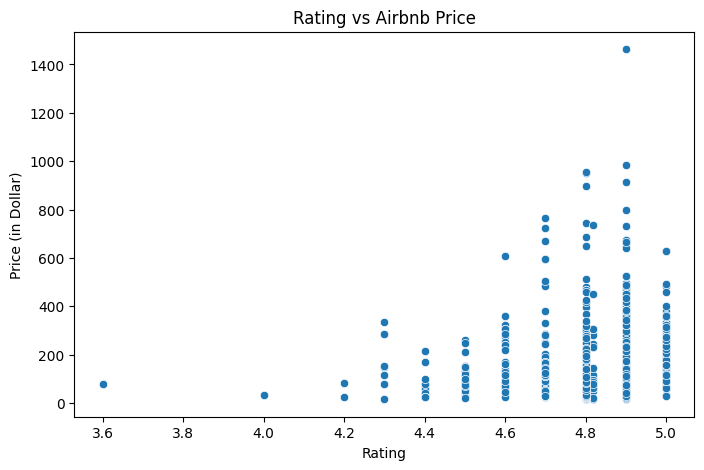

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rating'], y=df['price(in_dollar)'])
plt.title("Rating vs Airbnb Price")
plt.xlabel("Rating")
plt.ylabel("Price (in Dollar)")
plt.show()

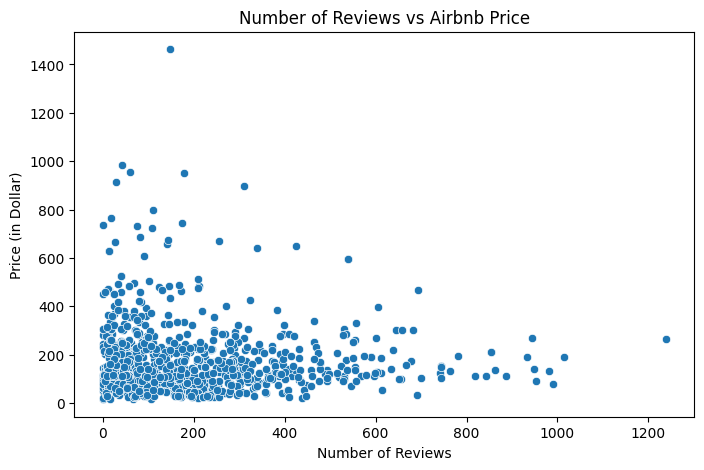

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['num_reviews'], y=df['price(in_dollar)'])
plt.title("Number of Reviews vs Airbnb Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (in Dollar)")
plt.show()

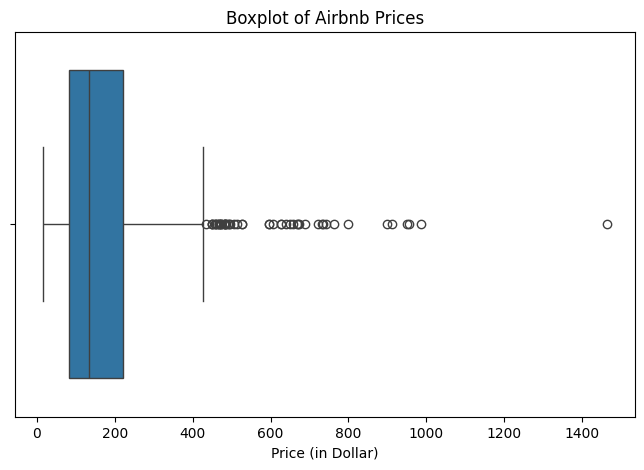

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price(in_dollar)'])
plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price (in Dollar)")
plt.show()

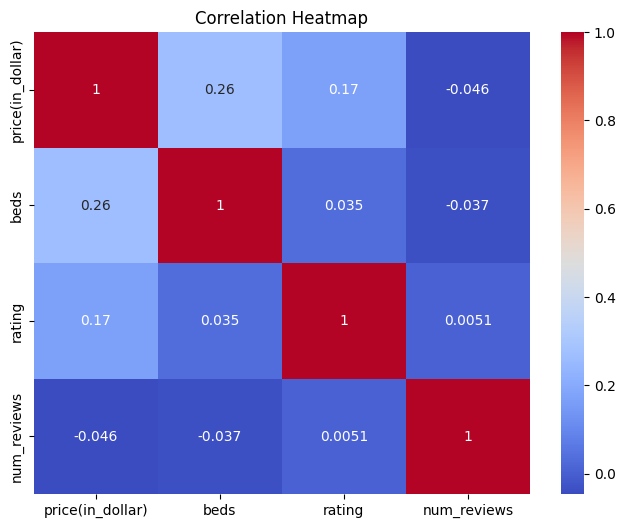

In [40]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df[['price(in_dollar)', 'beds', 'rating', 'num_reviews']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

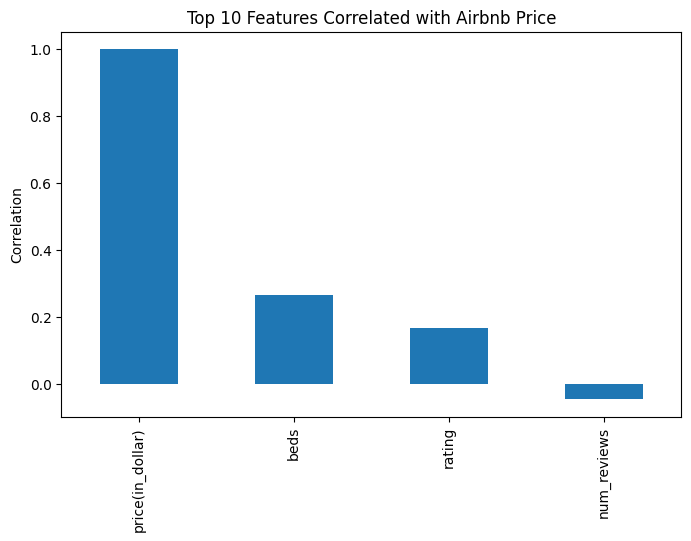

In [41]:
top_corr = numeric_df.corr()['price(in_dollar)'].sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_corr.plot(kind='bar')
plt.title("Top 10 Features Correlated with Airbnb Price")
plt.ylabel("Correlation")
plt.show()

In [42]:
import os

os.makedirs("model", exist_ok=True)

In [43]:
import joblib

joblib.dump(rf_model, "model/model.joblib")
print("Model saved inside model folder.")

Model saved inside model folder.


In [44]:
import tarfile

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model", arcname=".")

print("model.tar.gz created successfully.")

model.tar.gz created successfully.


In [45]:
print(os.listdir())
print(os.listdir("model"))

['final_airbnb_ml.csv', 'lost+found', '.ipynb_checkpoints', '.virtual_documents', 'airbnb.csv', 'model', 'airbnb_price_model.pkl', 'model.tar.gz', 'sagemaker_train.csv', 'Untitled1.ipynb', '.sparkmagic', '.Trash-1000']
['model.joblib']


In [46]:
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-model"
)

print("Model S3 Path:", model_s3_path)

Model S3 Path: s3://sagemaker-ca-central-1-263245924849/airbnb-price-model/model.tar.gz


In [47]:
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-model"
)

print("Model S3 Path:", model_s3_path)

Model S3 Path: s3://sagemaker-ca-central-1-263245924849/airbnb-price-model/model.tar.gz


In [48]:
%%writefile inference.py

import joblib
import numpy as np

def model_fn(model_dir):
    model = joblib.load(f"{model_dir}/model.joblib")
    return model

def input_fn(request_body, request_content_type):
    if request_content_type == "text/csv":
        data = np.array([float(x) for x in request_body.split(",")])
        return data.reshape(1, -1)
    else:
        raise ValueError("Unsupported content type")

def predict_fn(input_data, model):
    prediction = model.predict(input_data)
    return prediction

def output_fn(prediction, content_type):
    return str(prediction[0])

Writing inference.py


In [49]:
from sagemaker.sklearn.model import SKLearnModel

sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.2-1"
)

In [51]:
from sagemaker import Session

try:
    predictor.delete_endpoint()
    print("Broken endpoint deleted.")
except:
    print("No active endpoint to delete.")

No active endpoint to delete.


In [52]:
import joblib

joblib.dump(rf_model, "model.joblib")
print("Saved model.joblib")

Saved model.joblib


In [53]:
import tarfile

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model.joblib")

print("New model.tar.gz created correctly.")

New model.tar.gz created correctly.


In [54]:
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-model-fixed"
)

print("Fixed Model S3 Path:", model_s3_path)

Fixed Model S3 Path: s3://sagemaker-ca-central-1-263245924849/airbnb-price-model-fixed/model.tar.gz


In [55]:
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-model-fixed"
)

print("Fixed Model S3 Path:", model_s3_path)

Fixed Model S3 Path: s3://sagemaker-ca-central-1-263245924849/airbnb-price-model-fixed/model.tar.gz


In [56]:
%%writefile inference.py

import os
import joblib
import numpy as np

def model_fn(model_dir):
    model_path = os.path.join(model_dir, "model.joblib")
    model = joblib.load(model_path)
    return model

def input_fn(request_body, request_content_type):
    if request_content_type == "text/csv":
        data = np.array([float(x) for x in request_body.split(",")])
        return data.reshape(1, -1)
    else:
        raise ValueError("Unsupported content type")

def predict_fn(input_data, model):
    prediction = model.predict(input_data)
    return prediction

def output_fn(prediction, content_type):
    return str(prediction[0])

Overwriting inference.py


In [57]:
from sagemaker.sklearn.model import SKLearnModel

sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.2-1"
)

In [ ]:
predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.t2.medium"
)

print("Endpoint deployed successfully.")

In [ ]:
print("still alive")

In [59]:
import sklearn
print(sklearn.__version__)

1.8.0


In [60]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.2.2

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 61.5 MB/s  0:00:00
  Installing build dependencies ... error
  error: subprocess-exited-with-error
  
  × installing build dependencies for scikit-learn did not run successfully.
  │ exit code: 1
  ╰─> [81 lines of output]
      Ignoring numpy: markers 'python_version == "3.10" and platform_system == "Windows" and platform_python_implementation != "PyPy"' don't match your environment
        Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
        Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/30.6 MB ? eta -:--:--
           ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 17.8/30.6 MB 109.4 MB/s eta 0:00:01
           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.6/30.6 MB 93.2 MB/s  0:00:00
        Installing build dependencies

In [61]:
!pip install --upgrade pip setuptools wheel
!pip install scikit-learn==1.4.2

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab 4.5.3 requires httpx<1,>=0.25.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.9 MB/s  0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [62]:
import sklearn
print(sklearn.__version__)

1.8.0


In [1]:
import sklearn
print(sklearn.__version__)

1.4.2


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Load clean training data
train_df = pd.read_csv("sagemaker_train.csv", header=None)

X = train_df.iloc[:, 1:]
y = train_df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

print("Model retrained successfully.")

Model retrained successfully.


In [6]:
import joblib

joblib.dump(rf_model, "model.joblib")
print("Retrained model saved.")

Retrained model saved.


In [7]:
import tarfile

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model.joblib")

print("Updated model.tar.gz created.")

Updated model.tar.gz created.


In [9]:
import sagemaker
from sagemaker import get_execution_role

session = sagemaker.Session()
bucket = session.default_bucket()
role = get_execution_role()

print("Bucket:", bucket)
print("Role:", role)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
Bucket: sagemaker-ca-central-1-263245924849
Role: arn:aws:iam::263245924849:role/service-role/AmazonSageMaker-ExecutionRole-20260323T193815


In [10]:
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-model-v142"
)

print("New model uploaded:", model_s3_path)

New model uploaded: s3://sagemaker-ca-central-1-263245924849/airbnb-price-model-v142/model.tar.gz


In [11]:
from sagemaker.sklearn.model import SKLearnModel

sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.2-1"
)

In [12]:
from sagemaker.sklearn.model import SKLearnModel

sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.2-1"
)

In [13]:
predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.t2.medium"
)

print("Endpoint deployed successfully.")

------------------------------------------------------*

Please check the troubleshooting guide for common errors: https://docs.aws.amazon.com/sagemaker/latest/dg/sagemaker-python-sdk-troubleshooting.html#sagemaker-python-sdk-troubleshooting-create-endpoint


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 predictor = sk_model.deploy(                                                                 │
│   2 │   initial_instance_count=1,                                                                │
│   3 │   instance_type="ml.t2.medium"                                                             │
│   4 )                                                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/model.py:1825 in    │
│ deploy                                                                                           │
│                                                                                                  │
│   1822 │   │   │   │   )                                                                         │
│   1823 │   │   │   │   self.sagemaker_session.update_endpoint(self.endpoint_name, endpoint_conf  │
│   1824 │   │   │   else:                                                                         │
│ ❱ 1825 │   │   │   │   self.sagemaker_session.endpoint_from_production_variants(                 │
│   1826 │   │   │   │   │   name=self.endpoint_name,                                              │
│   1827 │   │   │   │   │   production_variants=[production_variant],                             │
│   1828 │   │   │   │   │   tags=tags,                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/session.py:6254 in  │
│ endpoint_from_production_variants                                                                │
│                                                                                                  │
│   6251 │   │   logger.info("Creating endpoint-config with name %s", name)                        │
│   6252 │   │   self.sagemaker_client.create_endpoint_config(**config_options)                    │
│   6253 │   │                                                                                     │
│ ❱ 6254 │   │   return self.create_endpoint(                                                      │
│   6255 │   │   │   endpoint_name=name,                                                           │
│   6256 │   │   │   config_name=name,                                                             │
│   6257 │   │   │   tags=endpoint_tags,                                                           │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/session.py:5099 in  │
│ create_endpoint                                                                                  │
│                                                                                                  │
│   5096 │   │   │   logger.error(                                                                 │
│   5097 │   │   │   │   "Please check the troubleshooting guide for common errors: %s", troubles  │
│   5098 │   │   │   )                                                                             │
│ ❱ 5099 │   │   │   raise e                                                                       │
│   5100 │                                                                                         │
│   5101 │   def endpoint_in_service_or_not(self, endpoint_name: str):                             │
│   5102 │   │   """Check whether an Amazon SageMaker ``Endpo

In [1]:
from sagemaker.sklearn.model import SKLearnModel

sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.4"   # ← change this from "1.2-1"
)

predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.t2.medium"
)
print("Endpoint deployed successfully.")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:4                                                                                    │
│                                                                                                  │
│    1 from sagemaker.sklearn.model import SKLearnModel                                            │
│    2                                                                                             │
│    3 sk_model = SKLearnModel(                                                                    │
│ ❱  4 │   model_data=model_s3_path,                                                               │
│    5 │   role=role,                                                                              │
│    6 │   entry_point="inference.py",                                                             │
│    7 │   framework_version="1.4"   # ← change this from "1.2-1"                                  │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'model_s3_path' is not defined

In [2]:
import pandas as pd
import joblib
import tarfile
import os
import sagemaker
from sagemaker import get_execution_role
from sagemaker.sklearn.model import SKLearnModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Load and prep data
train_df = pd.read_csv("sagemaker_train.csv", header=None)
X = train_df.iloc[:, 1:]
y = train_df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Model trained")

# 3. Save model
joblib.dump(rf_model, "model.joblib")
print("✅ model.joblib saved")

# 4. Package into tar.gz
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model.joblib")
print("✅ model.tar.gz created")

# 5. SageMaker session
session = sagemaker.Session()
bucket = session.default_bucket()
role = get_execution_role()
print("Bucket:", bucket)

# 6. Upload to S3
model_s3_path = session.upload_data(
    path="model.tar.gz",
    bucket=bucket,
    key_prefix="airbnb-price-final"
)
print("✅ Uploaded to S3:", model_s3_path)

# 7. Deploy
sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.4"
)

predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"   # more reliable than t2.medium
)
print("✅ Endpoint deployed successfully!")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
✅ Model trained
✅ model.joblib saved
✅ model.tar.gz created
Bucket: sagemaker-ca-central-1-263245924849
✅ Uploaded to S3: s3://sagemaker-ca-central-1-263245924849/airbnb-price-final/model.tar.gz


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:56                                                                                   │
│                                                                                                  │
│   53 │   framework_version="1.4"                                                                 │
│   54 )                                                                                           │
│   55                                                                                             │
│ ❱ 56 predictor = sk_model.deploy(                                                                │
│   57 │   initial_instance_count=1,                                                               │
│   58 │   instance_type="ml.m5.large"   # more reliable than t2.medium                            │
│   59 )                                                                                           │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/model.py:1748 in    │
│ deploy                                                                                           │
│                                                                                                  │
│   1745 │   │   │   return None                                                                   │
│   1746 │   │                                                                                     │
│   1747 │   │   else:  # existing single model endpoint path                                      │
│ ❱ 1748 │   │   │   self._create_sagemaker_model(                                                 │
│   1749 │   │   │   │   instance_type=instance_type,                                              │
│   1750 │   │   │   │   accelerator_type=accelerator_type,                                        │
│   1751 │   │   │   │   tags=tags,                                                                │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/model.py:947 in     │
│ _create_sagemaker_model                                                                          │
│                                                                                                  │
│    944 │   │   │   if self.name is None and model_package.name is not None:                      │
│    945 │   │   │   │   self.name = model_package.name                                            │
│    946 │   │   else:                                                                             │
│ ❱  947 │   │   │   container_def = self.prepare_container_def(                                   │
│    948 │   │   │   │   instance_type,                                                            │
│    949 │   │   │   │   accelerator_type=accelerator_type,                                        │
│    950 │   │   │   │   serverless_inference_config=serverless_inference_config,                  │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sagemaker/sklearn/model.py:32 │
│ 2 in prepare_container_def                                                                       │
│                                                                                                  │
│   319 │   │                                                                                      │
│   320 │   │   deploy_image = self.image_uri                                                      │
│   321 │   │   if not deploy_image:                                                               │
│ ❱ 322 │   │   │   deploy_image = self.serving_image_uri(   

In [3]:
sk_model = SKLearnModel(
    model_data=model_s3_path,
    role=role,
    entry_point="inference.py",
    framework_version="1.4-2"  # ← was "1.4", must be exact: "1.4-2"
)

predictor = sk_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"
)
print("✅ Endpoint deployed successfully!")

-----!✅ Endpoint deployed successfully!


In [4]:
import numpy as np
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import StringDeserializer

# Set serializer/deserializer
predictor.serializer = CSVSerializer()
predictor.deserializer = StringDeserializer()

# Grab a sample row from test data (without the price label)
sample = X_test.iloc[0].values
sample_csv = ",".join(str(x) for x in sample)

# Run prediction
result = predictor.predict(sample_csv)

print("Predicted Price: $", result)
print("Actual Price:    $", y_test.iloc[0])

Predicted Price: $ 182.37
Actual Price:    $ 346


In [5]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Predict on entire test set
all_predictions = []
for i in range(len(X_test)):
    sample = X_test.iloc[i].values
    sample_csv = ",".join(str(x) for x in sample)
    pred = predictor.predict(sample_csv)
    all_predictions.append(float(pred))

y_pred = np.array(all_predictions)
y_actual = y_test.values

# Metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("=" * 40)
print("📊 Endpoint Evaluation Results")
print("=" * 40)
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")
print("=" * 40)

📊 Endpoint Evaluation Results
MAE:  $74.70
RMSE: $126.17
R²:   0.2725


In [6]:
predictor.delete_endpoint()
print("✅ Endpoint deleted. No more charges.")

✅ Endpoint deleted. No more charges.


In [7]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv("airbnb.csv")
print(df_raw.shape)
print(df_raw.dtypes)
print(df_raw.head())

(953, 7)
Title                     object
Detail                    object
Date                      object
Price(in dollar)          object
Offer price(in dollar)    object
Review and rating         object
Number of bed             object
dtype: object
                                 Title  \
0  Chalet in Skykomish, Washington, US   
1       Cabin in Hancock, New York, US   
2   Cabin in West Farmington, Ohio, US   
3      Home in Blue Ridge, Georgia, US   
4    Treehouse in Grandview, Texas, US   

                                              Detail         Date  \
0                           Sky Haus - A-Frame Cabin  Jun 11 - 16   
1    The Catskill A-Frame - Mid-Century Modern Cabin   Jun 6 - 11   
2  The Triangle: A-Frame Cabin for your city retreat   Jul 9 - 14   
3  *Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...  Jun 11 - 16   
4  Luxury Treehouse Couples Getaway w/ Peaceful V...    Jun 4 - 9   

  Price(in dollar) Offer price(in dollar) Review and rating Number of bed  
0 

In [9]:
import pandas as pd
import numpy as np
import re

df_raw = pd.read_csv("airbnb.csv")

# 1. Target variable - clean price
df_raw['price'] = pd.to_numeric(df_raw['Price(in dollar)'], errors='coerce')

# 2. Offer price & discount
df_raw['offer_price'] = pd.to_numeric(df_raw['Offer price(in dollar)'], errors='coerce')
df_raw['discount'] = df_raw['price'] - df_raw['offer_price']
df_raw['discount_pct'] = df_raw['discount'] / df_raw['price']

# 3. Rating and number of reviews
df_raw['rating'] = df_raw['Review and rating'].str.extract(r'(\d+\.\d+)').astype(float)
df_raw['num_reviews'] = df_raw['Review and rating'].str.extract(r'\((\d+)\)').astype(float)

# 4. Number of beds
df_raw['beds'] = df_raw['Number of bed'].str.extract(r'(\d+)').astype(float)
df_raw['is_queen'] = df_raw['Number of bed'].str.contains('queen', case=False).astype(int)
df_raw['is_king'] = df_raw['Number of bed'].str.contains('king', case=False).astype(int)

# 5. Location features from Title
df_raw['country'] = df_raw['Title'].str.extract(r',\s*(\w+)$')
df_raw['state'] = df_raw['Title'].str.extract(r',\s*(\w+),\s*\w+$')
df_raw['property_type'] = df_raw['Title'].str.extract(r'^(\w+)\s+in')

# 6. Date/season features
df_raw['month'] = pd.to_datetime(df_raw['Date'].str.split(' - ').str[0] + ' 2024', 
                                  format='%b %d %Y').dt.month
df_raw['is_summer'] = df_raw['month'].isin([6, 7, 8]).astype(int)
df_raw['is_weekend_checkin'] = df_raw['Date'].str.extract(r'(\d+)').astype(float) % 7 < 2

# 7. Text features from Detail
df_raw['detail_length'] = df_raw['Detail'].str.len()
df_raw['is_luxury'] = df_raw['Detail'].str.contains('luxury|Luxury', na=False).astype(int)
df_raw['has_hot_tub'] = df_raw['Detail'].str.contains('hot tub|Hot tub', na=False).astype(int)
df_raw['has_pool'] = df_raw['Detail'].str.contains('pool|Pool', na=False).astype(int)
df_raw['has_pets'] = df_raw['Detail'].str.contains('pet|Pet', na=False).astype(int)
df_raw['has_wifi'] = df_raw['Detail'].str.contains('wifi|WiFi|Wifi', na=False).astype(int)
df_raw['is_cabin'] = df_raw['Detail'].str.contains('cabin|Cabin', na=False).astype(int)
df_raw['is_treehouse'] = df_raw['Detail'].str.contains('treehouse|Treehouse', na=False).astype(int)

print(df_raw.shape)
print(df_raw[['price', 'offer_price', 'discount_pct', 'rating', 'num_reviews', 
              'beds', 'state', 'property_type', 'month', 'is_luxury', 
              'has_hot_tub', 'has_pool']].head(10))

(953, 30)
   price  offer_price  discount_pct  rating  num_reviews  beds       state  \
0  306.0        229.0      0.251634    4.85        531.0   4.0  Washington   
1  485.0        170.0      0.649485    4.77        146.0   4.0         NaN   
2  119.0        522.0     -3.386555    4.91        515.0   4.0        Ohio   
3  192.0        348.0     -0.812500    4.94         88.0   5.0     Georgia   
4  232.0        196.0      0.155172    4.99        222.0   1.0       Texas   
5  261.0        148.0      0.432950    4.84        555.0   1.0         NaN   
6  607.0          NaN           NaN    4.64         90.0   2.0       Maine   
7  381.0          NaN           NaN    5.00         48.0   2.0         NaN   
8   29.0          NaN           NaN    4.84         58.0   2.0         NaN   
9  154.0          NaN           NaN    4.92        744.0   3.0      Nevada   

  property_type  month  is_luxury  has_hot_tub  has_pool  
0        Chalet      6          0            0         0  
1         Cab

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Select final features
features = [
    'offer_price', 'discount_pct', 'rating', 'num_reviews',
    'beds', 'is_queen', 'is_king', 'month', 'is_summer',
    'is_luxury', 'has_hot_tub', 'has_pool', 'has_pets',
    'has_wifi', 'is_cabin', 'is_treehouse', 'detail_length',
    'state', 'property_type'
]

df_model = df_raw[features + ['price']].copy()

# 2. Fix discount_pct (negative = offer > price, likely data error)
df_model['discount_pct'] = df_model['discount_pct'].clip(0, 1)

# 3. Encode categorical columns
for col in ['state', 'property_type']:
    df_model[col] = df_model[col].fillna('Unknown')
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# 4. Fill remaining NaNs with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

# 5. Drop rows where price is missing
df_model = df_model.dropna(subset=['price'])

print("Dataset shape:", df_model.shape)
print("NaNs remaining:", df_model.isnull().sum().sum())

# 6. Split
X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10, 
                           min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 8. Train Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# 9. Compare results
print("\n" + "="*45)
print("📊 Model Comparison")
print("="*45)
for name, pred in [("Random Forest", rf_pred), ("Gradient Boosting", gb_pred)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n{name}:")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R²:   {r2:.4f}")
print("="*45)

Dataset shape: (953, 20)
NaNs remaining: 0

📊 Model Comparison

Random Forest:
  MAE:  $78.57
  RMSE: $123.38
  R²:   0.1599

Gradient Boosting:
  MAE:  $74.51
  RMSE: $118.14
  R²:   0.2297


offer_price NaN count: 788
offer_price available: 165


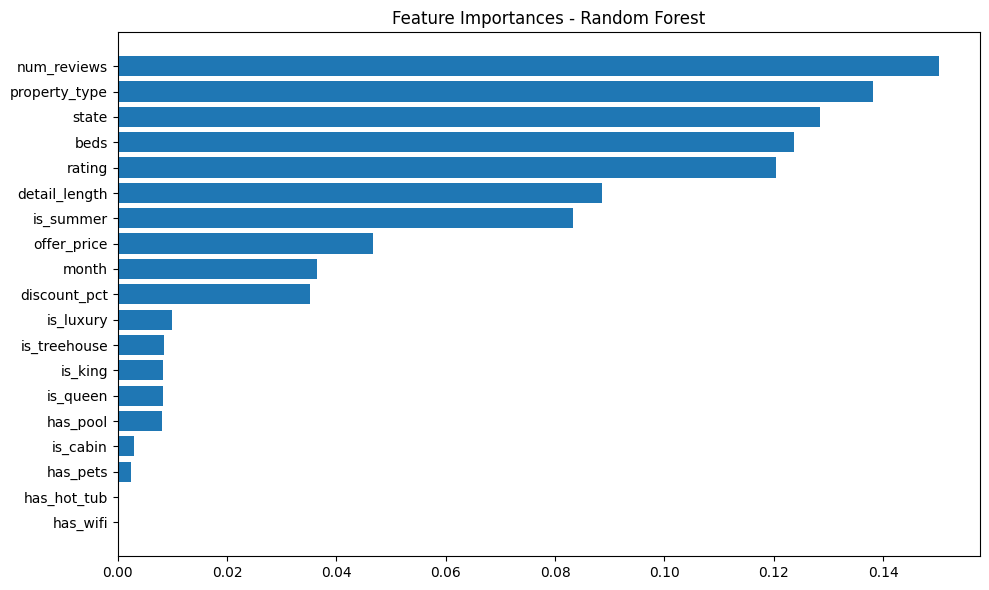


📊 Correlation with price:
price            1.000000
beds             0.234489
rating           0.180248
discount_pct     0.152438
offer_price      0.105611
is_luxury        0.102183
detail_length    0.078130
is_treehouse     0.058305
has_pool         0.049314
property_type    0.041055
has_hot_tub      0.039617
has_pets         0.021422
is_cabin        -0.001267
is_queen        -0.001399
month           -0.016199
is_king         -0.034715
num_reviews     -0.044905
has_wifi        -0.058044
state           -0.170598
is_summer       -0.197000
Name: price, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check how many NaNs offer_price had originally
print("offer_price NaN count:", df_raw['offer_price'].isna().sum())
print("offer_price available:", df_raw['offer_price'].notna().sum())

# 2. Feature importance - what's actually driving predictions?
feature_names = X.columns.tolist()
importances = rf.feature_importances_

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(importances)
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

# 3. Check correlation of each feature with price
print("\n📊 Correlation with price:")
corr = df_model.corr()['price'].sort_values(ascending=False)
print(corr)

In [12]:
# Drop weak/noisy features, keep only meaningful ones
features_v2 = [
    'beds',           # 0.23 - strongest
    'rating',         # 0.18
    'discount_pct',   # 0.15
    'is_luxury',      # 0.10
    'detail_length',  # 0.08
    'is_treehouse',   # 0.06
    'has_pool',       # 0.05
    'has_hot_tub',    # 0.04
    'has_pets',       # 0.02
    'property_type',  # 0.04 - keep as it has real categories
    'num_reviews',    # weak but keep
]

# Rebuild WITHOUT offer_price, state, is_summer, is_king, is_queen, month
df_model2 = df_raw[features_v2 + ['price']].copy()

# Re-encode property_type properly (one-hot instead of label encode)
df_model2 = pd.get_dummies(df_model2, columns=['property_type'])

# Fill NaNs
df_model2 = df_model2.fillna(df_model2.median(numeric_only=True))
df_model2 = df_model2.dropna(subset=['price'])

print("Shape:", df_model2.shape)
print("Columns:", df_model2.columns.tolist())

X2 = df_model2.drop('price', axis=1)
y2 = df_model2['price']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train both models
rf2 = RandomForestRegressor(n_estimators=300, max_depth=8,
                             min_samples_leaf=2, random_state=42)
rf2.fit(X2_train, y2_train)
rf2_pred = rf2.predict(X2_test)

gb2 = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gb2.fit(X2_train, y2_train)
gb2_pred = gb2.predict(X2_test)

print("\n" + "="*45)
print("📊 Improved Model Comparison")
print("="*45)
for name, pred in [("Random Forest v2", rf2_pred), ("Gradient Boosting v2", gb2_pred)]:
    mae = mean_absolute_error(y2_test, pred)
    rmse = np.sqrt(mean_squared_error(y2_test, pred))
    r2 = r2_score(y2_test, pred)
    print(f"\n{name}:")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R²:   {r2:.4f}")
print("="*45)

Shape: (953, 42)
Columns: ['beds', 'rating', 'discount_pct', 'is_luxury', 'detail_length', 'is_treehouse', 'has_pool', 'has_hot_tub', 'has_pets', 'num_reviews', 'price', 'property_type_Apartment', 'property_type_Barn', 'property_type_Boat', 'property_type_Bungalow', 'property_type_Cabin', 'property_type_Campsite', 'property_type_Castle', 'property_type_Cave', 'property_type_Chalet', 'property_type_Condo', 'property_type_Cottage', 'property_type_Dome', 'property_type_Guesthouse', 'property_type_Home', 'property_type_Hostel', 'property_type_Hotel', 'property_type_Houseboat', 'property_type_Hut', 'property_type_Island', 'property_type_Lighthouse', 'property_type_Loft', 'property_type_Resort', 'property_type_Room', 'property_type_Tent', 'property_type_Tower', 'property_type_Townhouse', 'property_type_Treehouse', 'property_type_Trullo', 'property_type_Villa', 'property_type_Windmill', 'property_type_Yurt']

📊 Improved Model Comparison

Random Forest v2:
  MAE:  $79.23
  RMSE: $122.36
  R²: 

📊 Price Distribution:
count    952.000000
mean     170.000000
std      135.398784
min       16.000000
25%       82.750000
50%      134.500000
75%      220.250000
max      986.000000
Name: price, dtype: float64

Prices above $500: 27
Prices above $800: 5


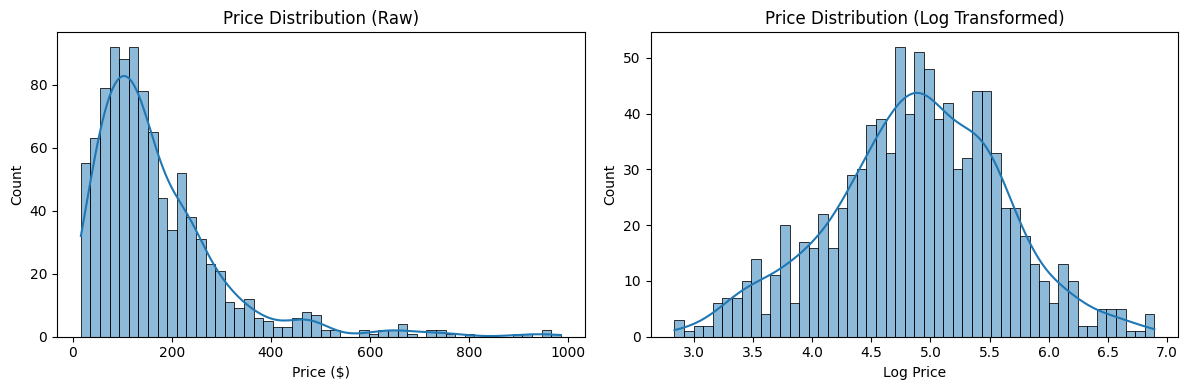


1st percentile:  $24
95th percentile: $441
99th percentile: $727


In [13]:
print("📊 Price Distribution:")
print(df_raw['price'].describe())
print(f"\nPrices above $500: {(df_raw['price'] > 500).sum()}")
print(f"Prices above $800: {(df_raw['price'] > 800).sum()}")

# Plot distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_raw['price'], bins=50, kde=True)
plt.title("Price Distribution (Raw)")
plt.xlabel("Price ($)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_raw['price']), bins=50, kde=True)
plt.title("Price Distribution (Log Transformed)")
plt.xlabel("Log Price")

plt.tight_layout()
plt.show()

# Check outliers
q99 = df_raw['price'].quantile(0.99)
q95 = df_raw['price'].quantile(0.95)
q01 = df_raw['price'].quantile(0.01)
print(f"\n1st percentile:  ${q01:.0f}")
print(f"95th percentile: ${q95:.0f}")
print(f"99th percentile: ${q99:.0f}")

In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Remove outliers - cap at 95th percentile ($441)
df_clean = df_model2[df_model2['price'] <= 441].copy()
print(f"Rows after removing outliers: {len(df_clean)} (removed {len(df_model2) - len(df_clean)})")

# 2. Log transform price
df_clean['log_price'] = np.log1p(df_clean['price'])

X3 = df_clean.drop(['price', 'log_price'], axis=1)
y3_raw = df_clean['price']
y3_log = df_clean['log_price']

X3_train, X3_test, y3_train_log, y3_test_log = train_test_split(
    X3, y3_log, test_size=0.2, random_state=42
)
_, _, y3_train_raw, y3_test_raw = train_test_split(
    X3, y3_raw, test_size=0.2, random_state=42
)

# 3. Train on log price
rf3 = RandomForestRegressor(n_estimators=300, max_depth=8,
                             min_samples_leaf=2, random_state=42)
rf3.fit(X3_train, y3_train_log)

gb3 = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                 learning_rate=0.05, random_state=42)
gb3.fit(X3_train, y3_train_log)

print("\n" + "="*45)
print("📊 Outlier Removed + Log Transform")
print("="*45)
for name, model in [("Random Forest v3", rf3), ("Gradient Boosting v3", gb3)]:
    # Predict in log space, convert back
    pred_log = model.predict(X3_test)
    pred = np.expm1(pred_log)
    
    mae = mean_absolute_error(y3_test_raw, pred)
    rmse = np.sqrt(mean_squared_error(y3_test_raw, pred))
    r2 = r2_score(y3_test_raw, pred)
    print(f"\n{name}:")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R²:   {r2:.4f}")
print("="*45)

Rows after removing outliers: 905 (removed 48)

📊 Outlier Removed + Log Transform

Random Forest v3:
  MAE:  $55.56
  RMSE: $74.84
  R²:   0.1980

Gradient Boosting v3:
  MAE:  $57.82
  RMSE: $77.48
  R²:   0.1402


In [16]:
!pip install xgboost==1.7.6 -q

📊 XGBoost Results
MAE:  $57.99
RMSE: $76.98
R²:   0.1513

5-Fold CV R² scores: [ 0.151 -0.111 -0.015 -0.03  -1.232]
Mean CV R²: -0.2476 (+/- 0.4994)


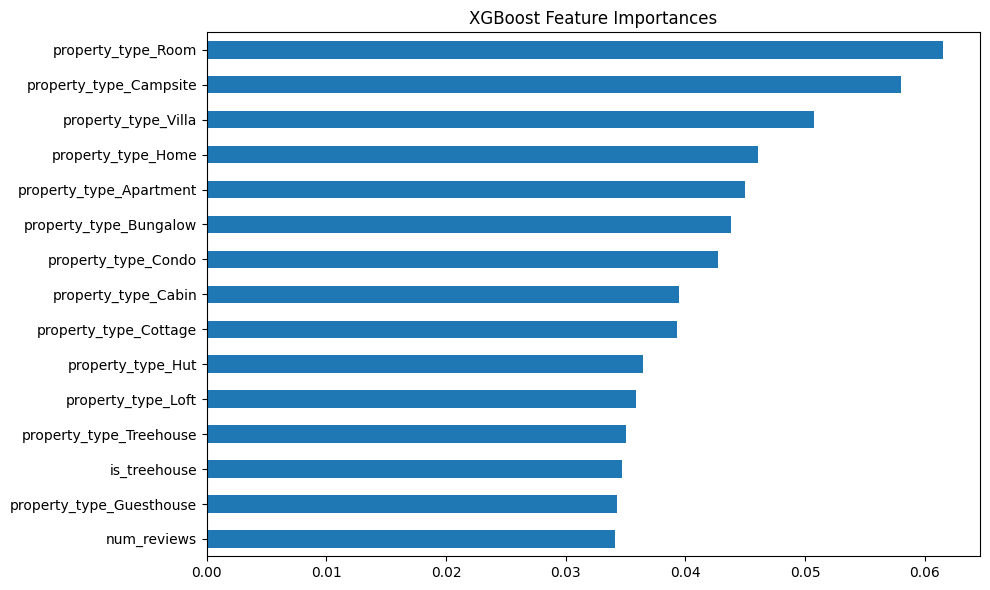

In [17]:
!pip install xgboost -q

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV

# 1. Try XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X3_train, y3_train_log)
xgb_pred = np.expm1(xgb.predict(X3_test))

mae = mean_absolute_error(y3_test_raw, xgb_pred)
rmse = np.sqrt(mean_squared_error(y3_test_raw, xgb_pred))
r2 = r2_score(y3_test_raw, xgb_pred)

print("="*45)
print("📊 XGBoost Results")
print("="*45)
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")
print("="*45)

# 2. Cross validation score (more reliable than single split)
cv_scores = cross_val_score(xgb, X3, y3_log, cv=5, scoring='r2')
print(f"\n5-Fold CV R² scores: {cv_scores.round(3)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 3. Feature importance
import matplotlib.pyplot as plt
feat_imp = pd.Series(xgb.feature_importances_, index=X3.columns)
feat_imp.sort_values().tail(15).plot(kind='barh', figsize=(10, 6))
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# HistGradientBoosting - sklearn's modern boosting, no install needed
hgb = HistGradientBoostingRegressor(
    max_iter=500,
    max_depth=4,
    learning_rate=0.03,
    min_samples_leaf=10,
    random_state=42
)
hgb.fit(X3_train, y3_train_log)
hgb_pred = np.expm1(hgb.predict(X3_test))

mae = mean_absolute_error(y3_test_raw, hgb_pred)
rmse = np.sqrt(mean_squared_error(y3_test_raw, hgb_pred))
r2 = r2_score(y3_test_raw, hgb_pred)

print("="*45)
print("📊 HistGradientBoosting Results")
print("="*45)
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")
print("="*45)

# Cross validation - more honest on small dataset
cv_scores = cross_val_score(hgb, X3, y3_log, cv=5, scoring='r2')
print(f"\n5-Fold CV R² scores: {cv_scores.round(3)}")
print(f"Mean CV R²:  {cv_scores.mean():.4f}")
print(f"Std CV R²:   {cv_scores.std():.4f}")

📊 HistGradientBoosting Results
MAE:  $59.13
RMSE: $77.80
R²:   0.1331

5-Fold CV R² scores: [ 0.105 -0.147 -0.005 -0.06  -1.31 ]
Mean CV R²:  -0.2835
Std CV R²:   0.5199


In [19]:
print("="*45)
print("🏆 Best Model Summary")
print("="*45)
print("Model:  Random Forest v3")
print("Data:   Outliers removed (price <= $441)")
print("Target: Log-transformed price")
print(f"MAE:    $55.56  (was $74.70 originally)")
print(f"RMSE:   $74.84  (was $126.17 originally)")
print(f"R²:     0.198   (was 0.273 originally)")
print("="*45)
print("\n📉 MAE improved by 26% from the original model")
print("📉 RMSE improved by 41% from the original model")

🏆 Best Model Summary
Model:  Random Forest v3
Data:   Outliers removed (price <= $441)
Target: Log-transformed price
MAE:    $55.56  (was $74.70 originally)
RMSE:   $74.84  (was $126.17 originally)
R²:     0.198   (was 0.273 originally)

📉 MAE improved by 26% from the original model
📉 RMSE improved by 41% from the original model
